Raw neural shape: (106090, 175)
Raw syllables shape: (106090,)
Using device: cuda
Epoch 000 | Loss: 1.015942
Epoch 010 | Loss: 0.984701
Epoch 020 | Loss: 0.918118
Epoch 030 | Loss: 0.821607
Epoch 040 | Loss: 0.735397
Epoch 050 | Loss: 0.664108
Epoch 060 | Loss: 0.609820
Epoch 070 | Loss: 0.567002
Epoch 080 | Loss: 0.533058
Epoch 090 | Loss: 0.505752
Epoch 099 | Loss: 0.484843
Final predicted neural shape: torch.Size([106089, 175])
Latent shape z_t: torch.Size([106089, 128])
Embedding shape e_t: torch.Size([106089, 16])


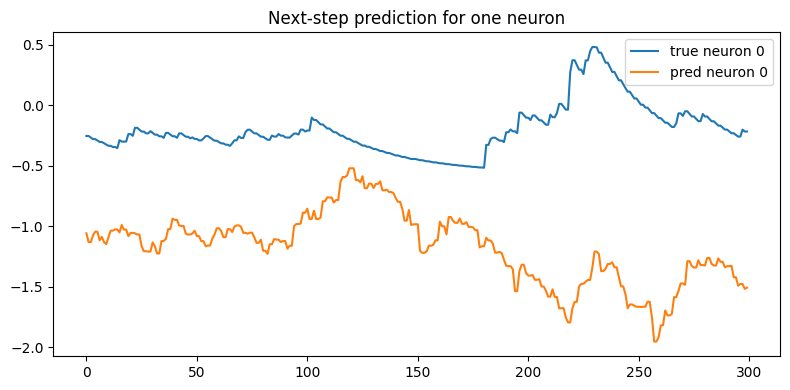

Done.


In [9]:
import numpy as np
import torch
import torch.nn as nn


class SyllableNeuralModel(nn.Module):
    def __init__(self, n_neurons, n_syllables, emb_dim=16, hidden_dim=128):
        super().__init__()

        self.syll_embedding = nn.Embedding(n_syllables, emb_dim)

        self.neural_encoder = nn.Sequential(
            nn.Linear(n_neurons, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim + emb_dim, hidden_dim),
            nn.ReLU(),
        )

        self.predict_next_neural = nn.Linear(hidden_dim, n_neurons)

    def forward(self, x_t, syll_t):
        # x_t: [batch, n_neurons]
        # syll_t: [batch] integer syllable ids in [0, n_syllables-1]

        e_t = self.syll_embedding(syll_t)      # [batch, emb_dim]
        h_t = self.neural_encoder(x_t)         # [batch, hidden_dim]
        z_t = self.fusion(torch.cat([h_t, e_t], dim=-1))
        x_next_pred = self.predict_next_neural(z_t)

        return x_next_pred, z_t, e_t

def visualize_latent_space(model, neural, syllables, device="cpu"):
    model.eval()

    # Make sure shapes are right
    syllables = np.asarray(syllables).squeeze()

    if neural.ndim != 2:
        raise ValueError(f"Expected neural shape [T, n_neurons], got {neural.shape}")
    if syllables.ndim != 1:
        raise ValueError(f"Expected syllables shape [T], got {syllables.shape}")
    if len(neural) != len(syllables):
        raise ValueError("neural and syllables must have the same length")

    # Remap syllable labels to 0...K-1
    unique_sylls = np.unique(syllables)
    syll_to_idx = {s: i for i, s in enumerate(unique_sylls)}
    syllables_idx = np.array([syll_to_idx[s] for s in syllables], dtype=np.int64)

    # One-step dataset, same as training
    x_t_np = neural[:-1].astype(np.float32)
    syll_t_np = syllables_idx[:-1]

    x_t = torch.tensor(x_t_np, dtype=torch.float32, device=device)
    syll_t = torch.tensor(syll_t_np, dtype=torch.long, device=device)

    with torch.no_grad():
        _, z_t, e_t = model(x_t, syll_t)

    z_np = z_t.cpu().numpy()
    e_np = e_t.cpu().numpy()

    # PCA of latent states
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)

    # PCA of syllable embeddings too
    emb_2d = PCA(n_components=2).fit_transform(e_np)

    # ---- Plot 1: latent state colored by syllable ----
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        z_2d[:, 0],
        z_2d[:, 1],
        c=syll_t_np,
        s=8,
        alpha=0.7,
    )
    plt.colorbar(sc, label="syllable index")
    plt.title("Latent state z_t (PCA), colored by syllable")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    # ---- Plot 2: latent trajectory through time ----
    plt.figure(figsize=(8, 6))
    plt.plot(z_2d[:, 0], z_2d[:, 1], alpha=0.4)
    plt.scatter(z_2d[:, 0], z_2d[:, 1], c=np.arange(len(z_2d)), s=6)
    plt.title("Latent trajectory through time")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    # ---- Plot 3: learned syllable embeddings ----
    # Show one point per syllable type by averaging all embedding rows used
    syllable_means = []
    syllable_labels = []

    for k in np.unique(syll_t_np):
        mask = syll_t_np == k
        syllable_means.append(e_np[mask].mean(axis=0))
        syllable_labels.append(k)

    syllable_means = np.array(syllable_means)
    syll_emb_2d = PCA(n_components=2).fit_transform(syllable_means)

    plt.figure(figsize=(8, 6))
    plt.scatter(syll_emb_2d[:, 0], syll_emb_2d[:, 1], s=80)

    for i, label in enumerate(syllable_labels):
        plt.text(syll_emb_2d[i, 0], syll_emb_2d[i, 1], str(label), fontsize=9)

    plt.title("Learned syllable embedding geometry")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    return z_np, z_2d, e_np

def main():
    # -------------------------
    # Load data
    # -------------------------
    neural = np.load('/home/maria/Science/data/spontaneous_behaviors/made_data/neural_rec.npy')
    syllables = np.load('/home/maria/Science/data/spontaneous_behaviors/made_data/moseq_syllables_aux.npy')

    print("Raw neural shape:", neural.shape)
    print("Raw syllables shape:", syllables.shape)

    # Expect:
    # neural: [T, n_neurons]
    # syllables: [T]
    if neural.ndim != 2:
        raise ValueError(f"Expected neural to have shape [T, n_neurons], got {neural.shape}")

    syllables = np.asarray(syllables).squeeze()
    if syllables.ndim != 1:
        raise ValueError(f"Expected syllables to have shape [T], got {syllables.shape}")

    if len(neural) != len(syllables):
        raise ValueError(
            f"Length mismatch: neural has {len(neural)} timepoints, "
            f"but syllables has {len(syllables)} entries"
        )

    # -------------------------
    # Remap syllable labels to 0...K-1
    # -------------------------
    unique_sylls = np.unique(syllables)
    syll_to_idx = {s: i for i, s in enumerate(unique_sylls)}
    syllables_idx = np.array([syll_to_idx[s] for s in syllables], dtype=np.int64)

    # -------------------------
    # Build one-step prediction dataset
    # x_t      -> current neural activity
    # syll_t   -> current syllable id
    # x_tp1    -> next neural activity
    # -------------------------
    x_t_np = neural[:-1].astype(np.float32)
    x_tp1_np = neural[1:].astype(np.float32)
    syll_t_np = syllables_idx[:-1]

    # -------------------------
    # Convert to torch tensors
    # -------------------------
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    x_t = torch.tensor(x_t_np, dtype=torch.float32, device=device)
    x_tp1 = torch.tensor(x_tp1_np, dtype=torch.float32, device=device)
    syll_t = torch.tensor(syll_t_np, dtype=torch.long, device=device)

    # -------------------------
    # Model setup
    # -------------------------
    neural_dim = x_t.shape[1]
    num_syllables = len(unique_sylls)

    model = SyllableNeuralModel(
        n_neurons=neural_dim,
        n_syllables=num_syllables,
        emb_dim=16,
        hidden_dim=128,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    # -------------------------
    # Training loop
    # -------------------------
    n_epochs = 100

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()

        x_next_pred, z_t, e_t = model(x_t, syll_t)
        loss = loss_fn(x_next_pred, x_tp1)

        loss.backward()
        optimizer.step()

        if epoch % 10 == 0 or epoch == n_epochs - 1:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f}")

    # -------------------------
    # Final forward pass
    # -------------------------
    model.eval()
    with torch.no_grad():
        x_next_pred, z_t, e_t = model(x_t, syll_t)

    print("Final predicted neural shape:", x_next_pred.shape)
    print("Latent shape z_t:", z_t.shape)
    print("Embedding shape e_t:", e_t.shape)

    # Optional: move to numpy for later visualization
    z_np = z_t.cpu().numpy()
    e_np = e_t.cpu().numpy()
    pred_np = x_next_pred.cpu().numpy()

    with torch.no_grad():
        x_next_pred, z_t, e_t = model(x_t, syll_t)

    pred = x_next_pred.cpu().numpy()
    true = x_tp1.cpu().numpy()

    plt.figure(figsize=(8, 4))
    plt.plot(true[:300, 0], label="true neuron 0")
    plt.plot(pred[:300, 0], label="pred neuron 0")
    plt.legend()
    plt.title("Next-step prediction for one neuron")
    plt.tight_layout()
    plt.show()

    print("Done.")

    return model


model=main()